<a href="https://colab.research.google.com/github/taneeshk12/IMLS/blob/main/CARLA_taneeshk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/2026.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import os

base_path = "/content/data/2026"

print(os.listdir(base_path))

['train.zip', 'test-night.zip', 'validation.zip', 'test.zip', 'test-fog.zip', 'test-town-01.zip']


In [4]:
data_folder = "/content/data/2026/"

# Loop through all zip files inside data/
for file_name in os.listdir(data_folder):

    if file_name.endswith(".zip"):

        zip_path = os.path.join(data_folder, file_name)

        # Folder name without .zip
        output_folder = os.path.join(
            "extracted",
            file_name.replace(".zip", "")
        )

        # Extract inner zip
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(output_folder)

        print(f"Extracted: {file_name}")

Extracted: train.zip
Extracted: test-night.zip
Extracted: validation.zip
Extracted: test.zip
Extracted: test-fog.zip
Extracted: test-town-01.zip


In [5]:
base_path = "/content/extracted/"

print(os.listdir(base_path))

['validation', 'test-fog', 'train', 'test-town-01', 'test', 'test-night']


In [6]:
train_path = os.path.join(base_path, "train/train")

print(os.listdir(train_path)[:10])

['weather.feather', 'labels.feather', 'gnss.feather', 'segmentation-front', 'sim.log', 'imu.feather', 'labels.csv', '.hydra', 'collisions.feather', 'rgb-front']


In [7]:
import pandas as pd

train_csv = pd.read_csv(
    "/content/extracted/train/train/labels.csv"
)

train_csv.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [8]:
print(train_csv.columns)

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [9]:
import os

image_folder = "/content/extracted/train/train/rgb-front"

images = os.listdir(image_folder)

print(images[:5])

['018290.jpg', '034640.jpg', '063720.jpg', '029110.jpg', '025150.jpg']


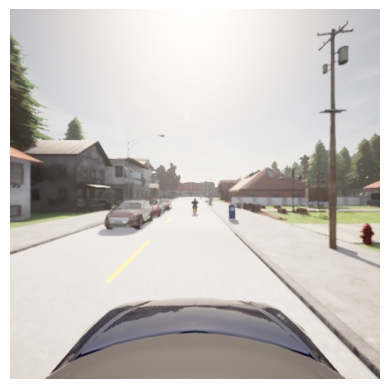

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

sample_img = images[0]

img_path = os.path.join(image_folder, sample_img)

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

## Exercise 3.4 - Dataset Exploration

In [11]:
import pandas as pd

train_csv = pd.read_csv(
    "/content/extracted/train/train/labels.csv"
)

val_csv = pd.read_csv(
    "/content/extracted/validation/validation/labels.csv"
)

test_csv = pd.read_csv(
    "/content/extracted/test/test/labels.csv"
)

In [12]:
train_csv.head(10)

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538
5,50,True,True,True,101,160,538
6,60,True,True,True,115,149,572
7,70,True,True,True,115,160,582
8,80,True,True,True,118,473,588
9,90,True,True,True,118,407,580


1) no of images

In [13]:
print("Train Images:", len(train_csv))
print("Validation Images:", len(val_csv))
print("Test Images:", len(test_csv))

Train Images: 7200
Validation Images: 3600
Test Images: 3600


2) check classes

In [14]:
print(train_csv['has_pedestrian'].value_counts())
print(train_csv['has_traffic_light'].value_counts())
print(train_csv['has_vehicle'].value_counts())

has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


3) see few example images

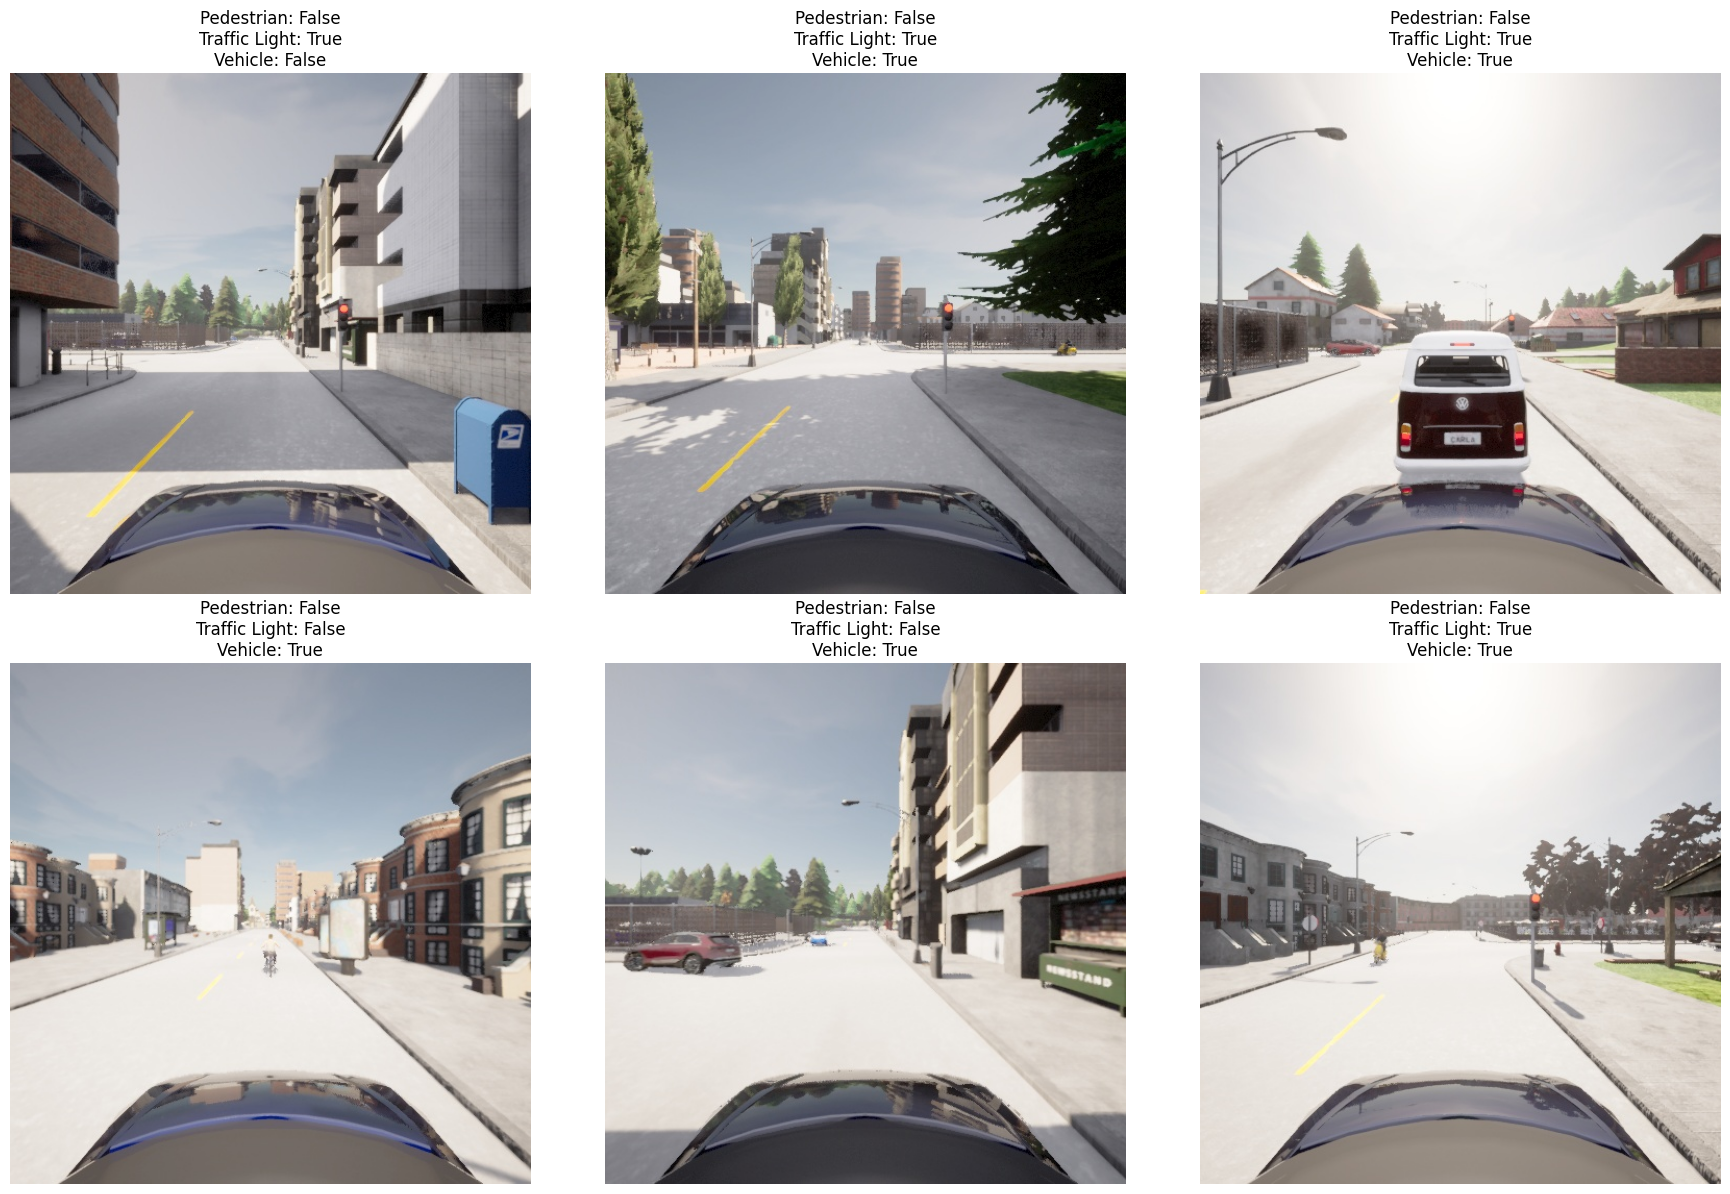

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# image folder
img_dir = "/content/extracted/train/train/rgb-front"

# create subplot for 6 images (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Get 6 random indices from the train_csv DataFrame
random_indices = random.sample(range(len(train_csv)), 6)

# loop through the selected random indices and corresponding axes
for i, ax in enumerate(axes.flat):

    # get row from csv using random index
    row = train_csv.iloc[random_indices[i]]

    # frame number
    frame = int(row['frame'])

    # convert to 6-digit format
    # 0 -> 000000
    # 10 -> 000010
    # 20 -> 000020
    img_name = f"{frame:06d}.jpg"

    # full image path
    img_path = os.path.join(img_dir, img_name)

    # open image
    img = Image.open(img_path)

    # display image
    ax.imshow(img)

    # labels
    title = (
        f"Pedestrian: {row['has_pedestrian']}\n"
        f"Traffic Light: {row['has_traffic_light']}\n"
        f"Vehicle: {row['has_vehicle']}"
    )

    ax.set_title(title)

    ax.axis("off")

plt.tight_layout()
plt.show()

# Exercise 3.5: Train Three Binary Classifiers

## Train the Dataset

In [18]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import torch
import os

class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = row[self.label_column]

        label = 1 if label else 0

        image = self.transform(image)

        label = torch.tensor(label).float()

        return image, label

### Pedestrian Model

In [ ]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# =========================================================
# TRANSFORMS
# =========================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
])

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),
])

# =========================================================
# DATASET
# =========================================================

class CarlaDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None
    ):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx][self.label_column]

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        # APPLY TRANSFORMS
        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# DATASETS
# =========================================================

train_dataset = CarlaDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_pedestrian",
    transform=train_transform
)

val_dataset = CarlaDataset(
    csv_file="/content/extracted/validation/validation/labels.csv",
    img_dir="/content/extracted/validation/validation/rgb-front/",
    label_column="has_pedestrian",
    transform=val_transform
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# =========================================================
# MODEL
# =========================================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# =========================================================
# FREEZE BACKBONE
# =========================================================

for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(
    model.fc.in_features,
    1
)

# Only train classifier layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model)

# =========================================================
# LOSS
# =========================================================

criterion = nn.BCEWithLogitsLoss()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)

# =========================================================
# LR SCHEDULER
# =========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

# =========================================================
# EARLY STOPPING
# =========================================================

best_val_loss = float('inf')

patience = 3

counter = 0

# =========================================================
# STORE LOSSES
# =========================================================

train_losses = []

val_losses = []

# =========================================================
# TRAINING LOOP
# =========================================================

epochs = 20

print("\n--- Training Pedestrian Detector ---\n")

for epoch in range(epochs):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    train_losses.append(train_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    val_losses.append(val_loss)

    # =====================================================
    # SCHEDULER STEP
    # =====================================================

    scheduler.step(val_loss)

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Models/pedestrian_model.pth"
        )

        print("Best model saved!")

        counter = 0

    else:

        counter += 1

    # =====================================================
    # EARLY STOPPING
    # =====================================================

    if counter >= patience:

        print("\nEarly stopping triggered!")

        break

print("\n--- Training Complete ---")

Using device: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): Re

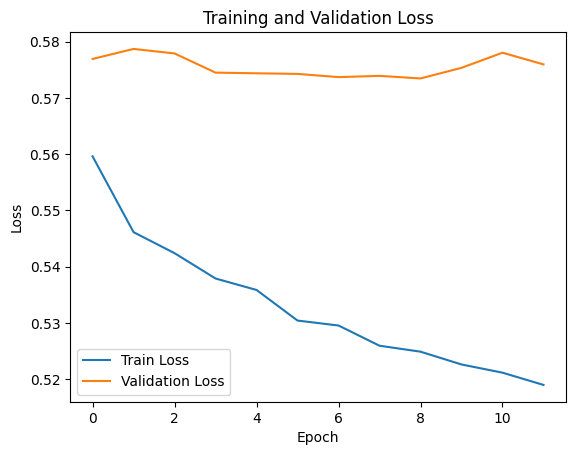

In [ ]:
plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
# torch.save(
#     model.state_dict(),
#     "/content/drive/MyDrive/Models/Pedestrian"
# )

## has_vehicles

In [ ]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# =========================================================
# TRANSFORMS
# =========================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
])

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),
])

# =========================================================
# DATASET
# =========================================================

class CarlaDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None
    ):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx][self.label_column]

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        # APPLY TRANSFORMS
        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# DATASETS
# =========================================================

train_dataset = CarlaDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_vehicle", # Changed to has_vehicle
    transform=train_transform
)

val_dataset = CarlaDataset(
    csv_file="/content/extracted/validation/validation/labels.csv",
    img_dir="/content/extracted/validation/validation/rgb-front/",
    label_column="has_vehicle", # Changed to has_vehicle
    transform=val_transform
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# =========================================================
# MODEL
# =========================================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# =========================================================
# FREEZE BACKBONE
# =========================================================

for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(
    model.fc.in_features,
    1
)

# Only train classifier layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model)

# =========================================================
# LOSS
# =========================================================

criterion = nn.BCEWithLogitsLoss()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)

# =========================================================
# LR SCHEDULER
# =========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

# =========================================================
# EARLY STOPPING
# =========================================================

best_val_loss = float('inf')

patience = 3

counter = 0

# =========================================================
# STORE LOSSES
# =========================================================

train_losses = []

val_losses = []

# =========================================================
# TRAINING LOOP
# =========================================================

epochs = 20

print("\n--- Training Vehicle Detector ---\n") # Changed print statement

for epoch in range(epochs):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    train_losses.append(train_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    val_losses.append(val_loss)

    # =====================================================
    # SCHEDULER STEP
    # =====================================================

    scheduler.step(val_loss)

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Models/vehicle_model.pth" # Changed save path
        )

        print("Best model saved!")

        counter = 0

    else:

        counter += 1

    # =====================================================
    # EARLY STOPPING
    # =====================================================

    if counter >= patience:

        print("\nEarly stopping triggered!")

        break

print("\n--- Training Complete ---")

Using device: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): Re

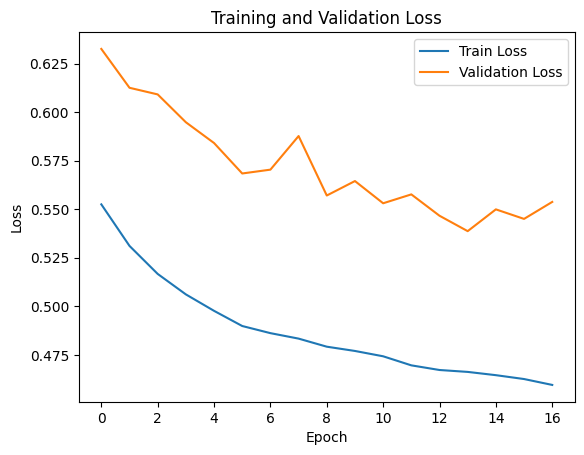

In [ ]:
plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
# torch.save(
#     model.state_dict(),
#     "vehicle_model.pth"
# )

## has_traffic_light

In [ ]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# =========================================================
# TRANSFORMS
# =========================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
])

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),
])

# =========================================================
# DATASET
# =========================================================

class CarlaDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None
    ):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx][self.label_column]

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        # APPLY TRANSFORMS
        if self.transform:
            image = self.transform(image)

        return image, label

# =========================================================
# DATASETS
# =========================================================

train_dataset = CarlaDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_traffic_light", # Changed to has_traffic_light
    transform=train_transform
)

val_dataset = CarlaDataset(
    csv_file="/content/extracted/validation/validation/labels.csv",
    img_dir="/content/extracted/validation/validation/rgb-front/",
    label_column="has_traffic_light", # Changed to has_traffic_light
    transform=val_transform
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# =========================================================
# MODEL
# =========================================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# =========================================================
# FREEZE BACKBONE
# =========================================================

for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(
    model.fc.in_features,
    1
)

# Only train classifier layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model)

# =========================================================
# LOSS
# =========================================================

criterion = nn.BCEWithLogitsLoss()

# =========================================================
# OPTIMIZER
# =========================================================

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)

# =========================================================
# LR SCHEDULER
# =========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

# =========================================================
# EARLY STOPPING
# =========================================================

best_val_loss = float('inf')

patience = 3

counter = 0

# =========================================================
# STORE LOSSES
# =========================================================

train_losses = []

val_losses = []

# =========================================================
# TRAINING LOOP
# =========================================================

epochs = 20

print("\n--- Training Traffic Light Detector ---\n") # Changed print statement

for epoch in range(epochs):

    # =====================================================
    # TRAIN
    # =====================================================

    model.train()

    running_train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    train_losses.append(train_loss)

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    val_losses.append(val_loss)

    # =====================================================
    # SCHEDULER STEP
    # =====================================================

    scheduler.step(val_loss)

    # =====================================================
    # PRINT RESULTS
# =====================================================

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/Models/traffic_light_model.pth" # Changed save path
        )

        print("Best model saved!")

        counter = 0

    else:

        counter += 1

    # =====================================================
    # EARLY STOPPING
    # =====================================================

    if counter >= patience:

        print("\nEarly stopping triggered!")

        break

print("\n--- Training Complete ---")

Using device: cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): Re

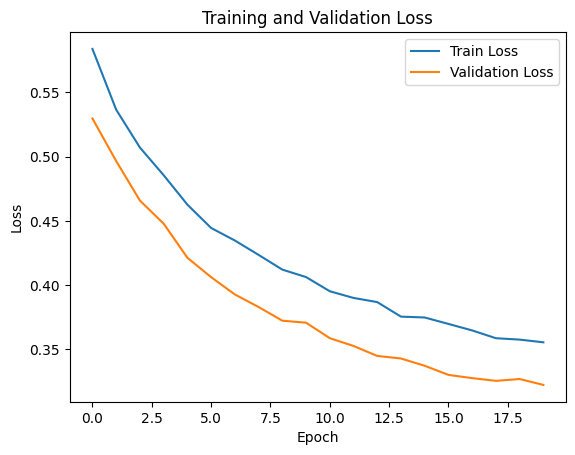

In [81]:
plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

In [ ]:
# torch.save(
#     model.state_dict(),
#     "traffic_model.pth"
# )

## Exercise 3.6: Evaluation

## Evaluate the model


In [82]:
pedestrian_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",

    img_dir="/content/extracted/test/test/rgb-front",

    label_column="has_pedestrian"
)

pedestrian_test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

In [83]:
vehicle_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",

    img_dir="/content/extracted/test/test/rgb-front",

    label_column="has_vehicle"
)

vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

In [84]:
traffic_light_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",

    img_dir="/content/extracted/test/test/rgb-front",

    label_column="has_traffic_light"
)

traffic_light_test_loader = DataLoader(
    traffic_light_test_dataset,
    batch_size=32,
    shuffle=False
)

In [85]:
pedestrian_model = "/content/drive/MyDrive/Models/pedestrian_model.pth"


In [86]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import numpy as np

def evaluate_model(model, loader):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            # move images to GPU/CPU
            images = images.to(device)

            # forward pass
            outputs = model(images)

            # logits -> probabilities
            probs = torch.sigmoid(outputs)

            # convert probabilities to binary predictions
            preds = (probs > 0.5).int()

            # flatten tensors
            preds = preds.squeeze(1)

            # store predictions
            predictions.extend(
                preds.cpu().numpy()
            )

            # store actual labels
            true_labels.extend(
                labels.numpy()
            )

    # convert to numpy arrays
    predictions = np.array(predictions)
    true_labels = np.array(true_labels)

    # calculate metrics
    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    precision = precision_score(
        true_labels,
        predictions
    )

    recall = recall_score(
        true_labels,
        predictions
    )

    f1 = f1_score(
        true_labels,
        predictions
    )

    # print metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return accuracy, precision, recall, f1

In [89]:
import torch.nn as nn
from torchvision.models import resnet18
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

# Instantiate the model architecture
pedestrian_model_instance = resnet18(pretrained=False) # No need for pretrained weights here, we load our own
pedestrian_model_instance.fc = nn.Linear(
    pedestrian_model_instance.fc.in_features,
    1
)

# Load the state dictionary
pedestrian_model_path = "/content/drive/MyDrive/Models/pedestrian_model.pth"
pedestrian_model_instance.load_state_dict(torch.load(pedestrian_model_path))

# Move the model to the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pedestrian_model_instance.to(device)

# Define the transform for the test dataset
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Re-create pedestrian_test_dataset with the correct transform
pedestrian_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_pedestrian",
    transform=val_transform # Pass the transform here
)

# Re-create pedestrian_test_loader
pedestrian_test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

evaluate_model(
    pedestrian_model_instance,
    pedestrian_test_loader
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Accuracy : 0.8039
Precision: 0.5000
Recall   : 0.0042
F1 Score : 0.0084


(0.8038888888888889, 0.5, 0.00424929178470255, 0.008426966292134831)

In [91]:
import torch.nn as nn
from torchvision.models import resnet18
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the transform for the test dataset
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Re-create vehicle_test_dataset with the correct transform
vehicle_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_vehicle",
    transform=val_transform # Pass the transform here
)

# Re-create vehicle_test_loader
vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

# Re-create traffic_light_test_dataset with the correct transform
traffic_light_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_traffic_light",
    transform=val_transform # Pass the transform here
)

# Re-create traffic_light_test_loader
traffic_light_test_loader = DataLoader(
    traffic_light_test_dataset,
    batch_size=32,
    shuffle=False
)

# --- Evaluate Vehicle Model ---
print("\n--- Evaluating Vehicle Model ---")
# Instantiate the model architecture
vehicle_model_instance = resnet18(pretrained=False) # No need for pretrained weights here, we load our own
vehicle_model_instance.fc = nn.Linear(
    vehicle_model_instance.fc.in_features,
    1
)

# Load the state dictionary
vehicle_model_path = "/content/drive/MyDrive/Models/vehicle_model.pth"
vehicle_model_instance.load_state_dict(torch.load(vehicle_model_path))

# Move the model to the correct device
vehicle_model_instance.to(device)

evaluate_model(
    vehicle_model_instance,
    vehicle_test_loader
)

# --- Evaluate Traffic Light Model ---
print("\n--- Evaluating Traffic Light Model ---")
# Instantiate the model architecture
traffic_light_model_instance = resnet18(pretrained=False) # No need for pretrained weights here, we load our own
traffic_light_model_instance.fc = nn.Linear(
    traffic_light_model_instance.fc.in_features,
    1
)

# Load the state dictionary
traffic_model_path = "/content/drive/MyDrive/Models/traffic_light_model.pth"
traffic_light_model_instance.load_state_dict(torch.load(traffic_model_path))

# Move the model to the correct device
traffic_light_model_instance.to(device)

evaluate_model(
    traffic_light_model_instance,
    traffic_light_test_loader
)


--- Evaluating Vehicle Model ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Accuracy : 0.7753
Precision: 0.7930
Recall   : 0.9478
F1 Score : 0.8635

--- Evaluating Traffic Light Model ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Accuracy : 0.8444
Precision: 0.8385
Recall   : 0.9702
F1 Score : 0.8995


(0.8444444444444444,
 0.8384615384615385,
 0.9702012383900929,
 0.8995335486185863)

## Exercise 4.5: ODD Coverage with k-Projection Coverage

In [92]:
from dataclasses import dataclass
from itertools import combinations, product
from typing import Any, Dict, Iterable, List, Optional, Tuple, TypeVar
from abc import ABC, abstractmethod
from typing import TypeVar

__all__ = ["KCoverageResult", "KProjectionCoverage"]

Self = TypeVar("Self")

class Metric(ABC):
    def __init__(self, *args, **kwargs) -> None:
        pass

    @abstractmethod
    def update(self: Self, *args, **kwargs) -> Self:
        """
        Add values to the metric
        """
        raise NotImplementedError

    @abstractmethod
    def compute(self, *args, **kwargs):
        """
        Compute the metric
        """
        raise NotImplementedError


class Projection:
    """
    A single projection
    """

    def __init__(self, n_values: List[int], names: Optional[List[str]] = None) -> None:
        """
        Holds a subspace with the cartesian product of some dimension and
        monitors coverage for this subspace.

        :param n_values: list with number of values for each dimension in this projection
        :param names: name of dimensions of this projection. just for debugging
        """
        self.n_options = n_values
        self.names = names or []

        # counts hits for all points in subspace
        self.counts: Dict[Tuple[int], int] = {}

        for point in product(*[range(i) for i in n_values]):
            self.counts[point] = 0

    @property
    def points(self) -> Iterable[Tuple[int]]:
        """
        :returns: iterator over all points in this subspace
        """
        return self.counts.keys()

    def is_covered(self, point: Tuple[int]) -> bool:
        """
        Checks of the particular point has been covered.
        We consider it covered if it has been covered at least once.
        """
        return self.counts[point] > 0

    @property
    def n_covered(self) -> int:
        """
        number of covered points in this subspace
        """
        return sum([int(count > 0) for count in self.counts.values()])

    @property
    def n_points(self) -> None:
        """
        number of points in this subspace
        """
        return len(self.counts)

    def reset(self) -> None:
        for key in self.counts:
            self.counts[key] = 0

    def cover(self, point: Tuple[int]) -> None:
        """
        mark point as covered
        """
        self.counts[point] += 1

    def __repr__(self) -> str:
        if self.names:
            return f'Projection({",".join(self.names)})'
        else:
            return "Projection()"

    @property
    def k(self) -> int:
        return len(self.n_options)


@dataclass
class KCoverageResult:
    """
    Result of k-projection coverage calculation.

    Args:
        coverage: The proportion of covered points over the total points (a float between 0 and 1).
        k: The number of dimensions used in the projection.
        covered: The number of points that are covered by the added scenarios.
        total: The total number of points in the k-dimensional space.
        scenes: The total number of scenarios that have been added.
    """

    coverage: float
    k: int
    covered: int
    total: int
    scenes: int


class KProjectionCoverage(Metric):
    """
    Preliminary implementation of Quantitative Projection Coverage from the paper
    [Quantitative Projection Coverage for Testing ML-enabled Autonomous Systems](https://arxiv.org/abs/1805.04333).

    **Note: This implementation is still missing some features, such as weighting.**

    Examples:
        How to use this metric:

            description = {
                "weather": ["good", "bad", "ugly"],
                "temperature": [1, 2, 3, 4],
                "humidity": [0.1, 0.2, 0.3, 0.4, 0.5],
            }

            cov = KProjectionCoverage(k=2, desc=description)

            cov.add_scenario({"weather": "bad", "temperature": 1, "humidity": 0.1})
            cov.add_scenario({"weather": "ugly", "temperature": 2, "humidity": 0.1})
            cov.add_scenario({"weather": "good", "temperature": 2, "humidity": 0.1})
            cov.add_scenario({"weather": "good", "temperature": 3, "humidity": 0.1})
            cov.add_scenario({"weather": "good", "temperature": 4, "humidity": 0.1})

            print(cov.compute())
    """

    def __init__(self, k: int, desc: Dict[str, List[Any]]) -> None:
        """
        Initializes the KProjectionCoverage metric.

        Args:
            k: The number of dimensions in the projection space (k <= total dimensions).
            desc: Domain description, a dictionary mapping each dimension to its list of possible values.
        """
        assert k <= len(desc)

        self.desc = desc
        self.k = k
        self.n_scenes = 0

        self.dims = list(desc.keys())
        self.n_dim_values = [len(desc[v]) for v in self.dims]

        # Maps (dimension, value) pairs to an integer index for efficiency.
        self.dim_value_to_index: Dict[Tuple[str, Any], int] = {}

        for d in self.dims:
            for n, o in enumerate(desc[d]):
                self.dim_value_to_index[(d, o)] = n

        # Projections identified by tuples of their corresponding dimensions.
        self.projections: Dict[Tuple[int], Projection] = {}

        # Create all k-dimensional projections
        for c in combinations(range(self.n_dims), r=self.k):
            self.projections[c] = Projection(
                n_values=[self.n_dim_values[j] for j in c],
                names=[self.dims[j] for j in c],
            )

    def reset(self) -> None:
        """
        Resets all projections, clearing the coverage data.
        """
        for p in self.projections.values():
            p.reset()

    @property
    def n_dims(self) -> int:
        """
        Returns the number of dimensions described by the domain.

        Returns:
            int: Number of dimensions.
        """
        return len(self.dims)

    def add_scenario(self, scenario: Dict[str, Any]) -> None:
        """
        Adds a new scenario to the coverage calculation.

        Args:
            scenario: A dictionary mapping each dimension to a value representing a scenario.
        """
        assert len(scenario) == self.n_dims

        # Convert the scenario description to its integer representation.
        scene = [self.dim_value_to_index[d, scenario[d]] for d in self.dims]

        # Update each k-dimensional projection with the new scenario.
        for c, projection in self.projections.items():
            point = tuple(scene[i] for i in c)
            projection.cover(point)

        self.n_scenes += 1

    def add_scenarios(self, scenarios: Iterable[Dict[str, Any]]) -> None:
        """
        Adds multiple scenarios to the coverage calculation.

        Args:
            scenarios: An iterable of dictionaries where each dictionary represents a scenario.
        """
        for scene in scenarios:
            self.add_scenario(scene)

    def update(self: Self, scenarios: Iterable[Dict[str, Any]]) -> Self:
        """
        Updates the coverage calculation with multiple scenarios.

        Args:
            scenarios: An iterable of dictionaries where each dictionary represents a scenario.

        Returns:
            Self: Returns the current instance to allow method chaining.
        """
        self.add_scenarios(scenarios=scenarios)
        return self

    def compute(self) -> KCoverageResult:
        """
        Computes the current coverage metrics based on the added scenarios.

        Returns:
            KCoverageResult: A result object containing coverage, total points, covered points, and the number of scenes.
        """
        covered = 0
        total = 0

        # Calculate total and covered points for each projection.
        for projection in self.projections.values():
            total += projection.n_points
            covered += projection.n_covered

        coverage = covered / total

        return KCoverageResult(
            coverage=coverage,
            k=self.k,
            covered=covered,
            total=total,
            scenes=self.n_scenes,
        )

In [93]:
# Define ODD dimensions
description = {
    "weather": ["sunny", "fog"],
    "lighting": ["day", "night"],
    "town": ["default", "town01"]
}

# Define scenarios represented by your test sets
scenarios = [

    # normal test set
    {
        "weather": "sunny",
        "lighting": "day",
        "town": "default"
    },

    # fog test set
    {
        "weather": "fog",
        "lighting": "day",
        "town": "default"
    },

    # night test set
    {
        "weather": "sunny",
        "lighting": "night",
        "town": "default"
    },

    # different town test set
    {
        "weather": "sunny",
        "lighting": "day",
        "town": "town01"
    }
]

# Compute coverage for k = 1, 2, 3
for k in [1, 2, 3]:

    cov = KProjectionCoverage(
        k=k,
        desc=description
    )

    # add scenarios
    cov.add_scenarios(scenarios)

    # compute result
    result = cov.compute()

    print(f"\n===== k = {k} ===")

    print("Coverage :", result.coverage)

    print("Covered  :", result.covered)

    print("Total    :", result.total)

    print("Scenes   :", result.scenes)



===== k = 1 ===
Coverage : 1.0
Covered  : 6
Total    : 6
Scenes   : 4

===== k = 2 ===
Coverage : 0.75
Covered  : 9
Total    : 12
Scenes   : 4

===== k = 3 ===
Coverage : 0.5
Covered  : 4
Total    : 8
Scenes   : 4


In [94]:
# pedestrian_model = '/content/pedestrian_model.pth'
# vehicle_model = '/content/vehicle_model.pth'
# traffic_model = '/content/traffic_model.pth'

## Exercise 4.7: Per-Class Evaluation

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_confusion_matrix(model, loader, title):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            preds = preds.squeeze(1)

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

    # confusion matrix
    cm = confusion_matrix(
        true_labels,
        predictions
    )

    # plot
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["False", "True"],
        yticklabels=["False", "True"]
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.title(title)

    plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


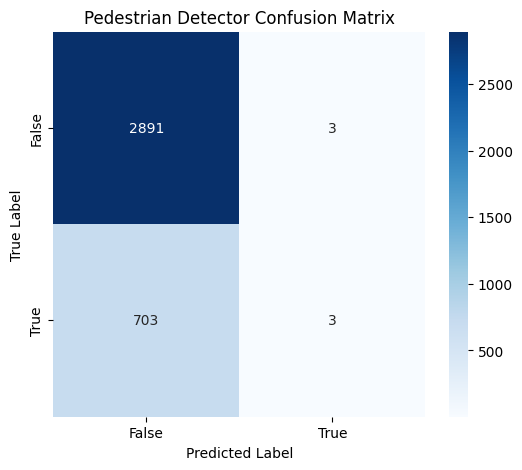

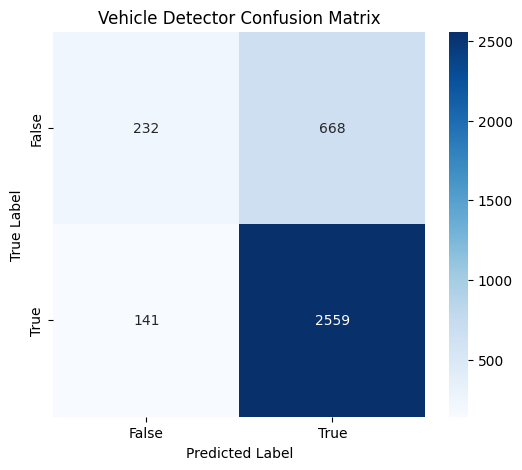

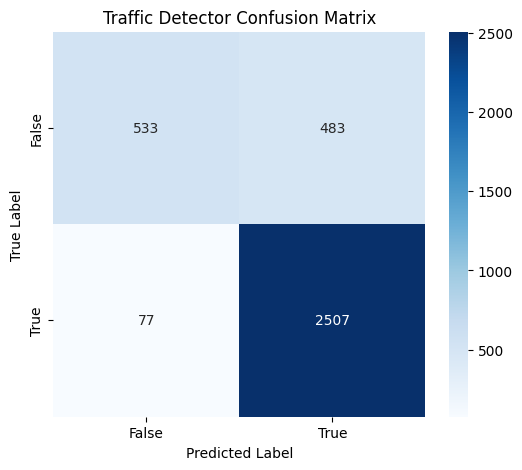

In [98]:
import torch.nn as nn
from torchvision.models import resnet18
import torch
from torch.utils.data import DataLoader
from torchvision import transforms # Import transforms

# Assuming CarlaDataset is defined in a previously executed cell (K3GnsGca5x6n or VbbTCE52GEas)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the transform for the test dataset
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# --- Re-create Test DataLoaders (as pedestrian_test_loader was not defined) ---
pedestrian_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_pedestrian",
    transform=val_transform # Pass the transform here
)
pedestrian_test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

vehicle_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_vehicle",
    transform=val_transform # Pass the transform here
)
vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

traffic_light_test_dataset = CarlaDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front",
    label_column="has_traffic_light",
    transform=val_transform # Pass the transform here
)
traffic_light_test_loader = DataLoader(
    traffic_light_test_dataset,
    batch_size=32,
    shuffle=False
)


# --- Load Model Instances ---

# Pedestrian Model
pedestrian_model_instance = resnet18(pretrained=False)
pedestrian_model_instance.fc = nn.Linear(pedestrian_model_instance.fc.in_features, 1)
pedestrian_model_path = "/content/drive/MyDrive/Models/pedestrian_model.pth" # Corrected path
pedestrian_model_instance.load_state_dict(torch.load(pedestrian_model_path))
pedestrian_model_instance.to(device)

# Vehicle Model
vehicle_model_instance = resnet18(pretrained=False)
vehicle_model_instance.fc = nn.Linear(vehicle_model_instance.fc.in_features, 1)
vehicle_model_path = "/content/drive/MyDrive/Models/vehicle_model.pth" # Corrected path
vehicle_model_instance.load_state_dict(torch.load(vehicle_model_path))
vehicle_model_instance.to(device)

# Traffic Light Model
traffic_light_model_instance = resnet18(pretrained=False)
traffic_light_model_instance.fc = nn.Linear(traffic_light_model_instance.fc.in_features, 1)
traffic_model_path = "/content/drive/MyDrive/Models/traffic_light_model.pth" # Corrected path
traffic_light_model_instance.load_state_dict(torch.load(traffic_model_path))
traffic_light_model_instance.to(device)


# --- Plot Confusion Matrices ---
plot_confusion_matrix(
    pedestrian_model_instance, # Pass the loaded model instance
    pedestrian_test_loader,
    "Pedestrian Detector Confusion Matrix"
)

plot_confusion_matrix(
    vehicle_model_instance, # Pass the loaded model instance
    vehicle_test_loader,
    "Vehicle Detector Confusion Matrix"
)
plot_confusion_matrix(
    traffic_light_model_instance, # Pass the loaded model instance
    traffic_light_test_loader,
    "Traffic Detector Confusion Matrix"
)

cuda


################################################
TEST SET: Normal Test
################################################

Pedestrian Detector | Normal Test
Accuracy : 0.8039
Precision: 0.5000
Recall   : 0.0042
F1 Score : 0.0084


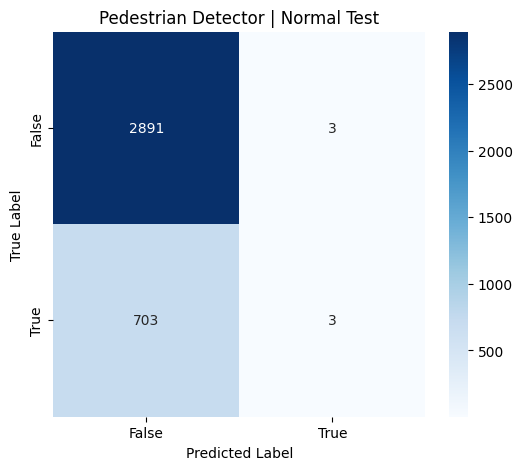


Vehicle Detector | Normal Test
Accuracy : 0.7753
Precision: 0.7930
Recall   : 0.9478
F1 Score : 0.8635


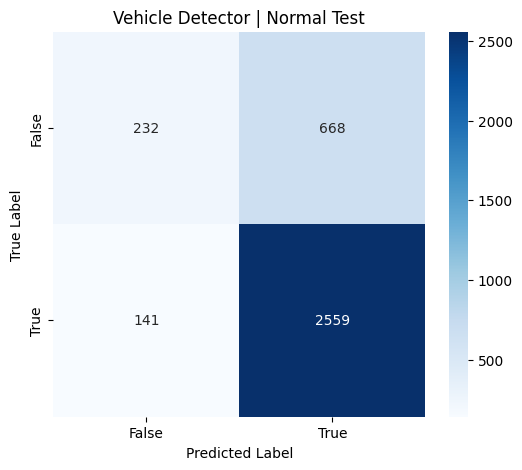


Traffic Light Detector | Normal Test
Accuracy : 0.8444
Precision: 0.8385
Recall   : 0.9702
F1 Score : 0.8995


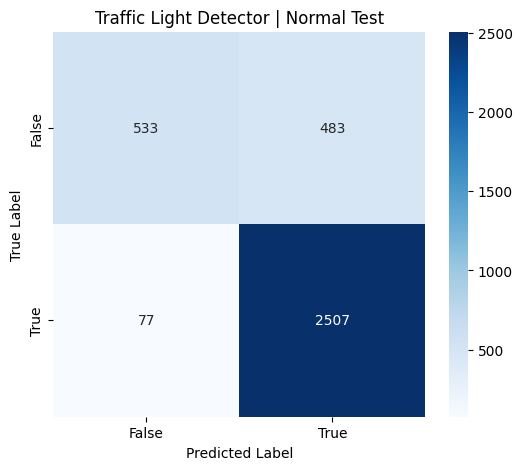



################################################
TEST SET: Fog Test
################################################

Pedestrian Detector | Fog Test
Accuracy : 0.7958
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


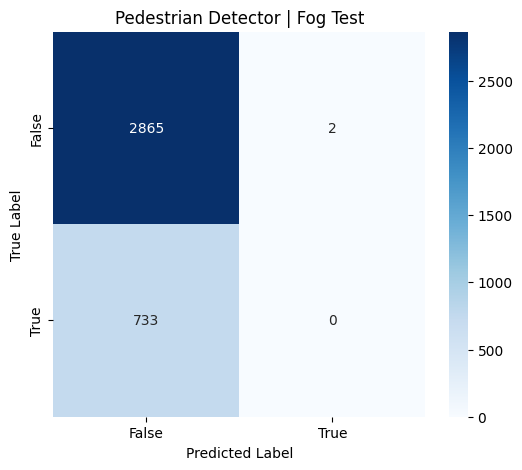


Vehicle Detector | Fog Test
Accuracy : 0.7814
Precision: 0.7800
Recall   : 0.9993
F1 Score : 0.8761


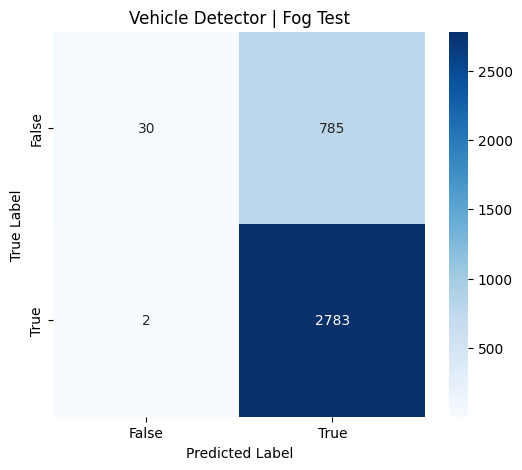


Traffic Light Detector | Fog Test
Accuracy : 0.7747
Precision: 0.8094
Recall   : 0.9040
F1 Score : 0.8541


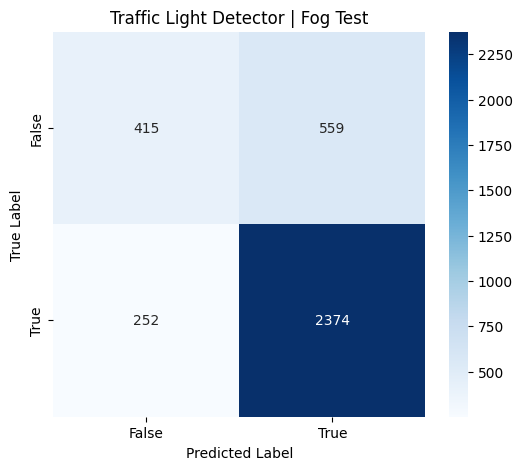



################################################
TEST SET: Night Test
################################################

Pedestrian Detector | Night Test
Accuracy : 0.7850
Precision: 0.1500
Recall   : 0.0123
F1 Score : 0.0227


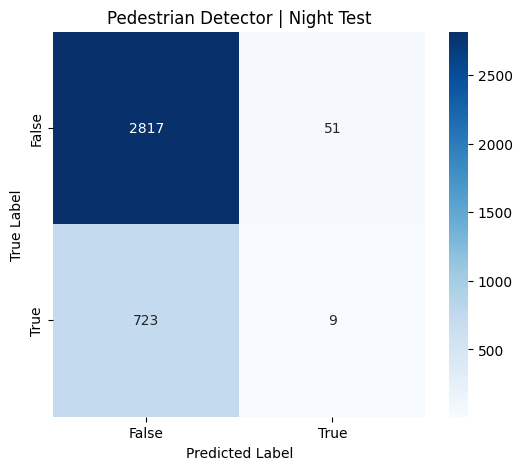


Vehicle Detector | Night Test
Accuracy : 0.7850
Precision: 0.7838
Recall   : 0.9971
F1 Score : 0.8777


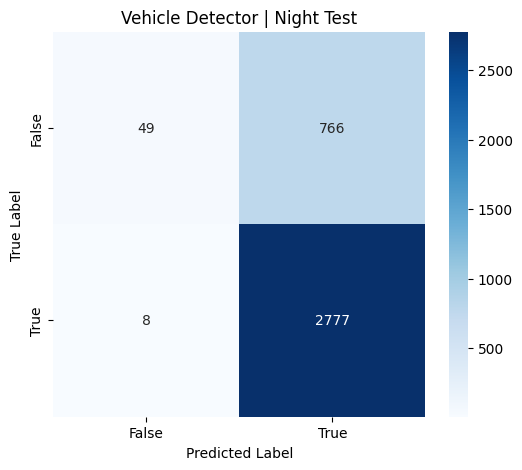


Traffic Light Detector | Night Test
Accuracy : 0.7681
Precision: 0.8363
Recall   : 0.8481
F1 Score : 0.8422


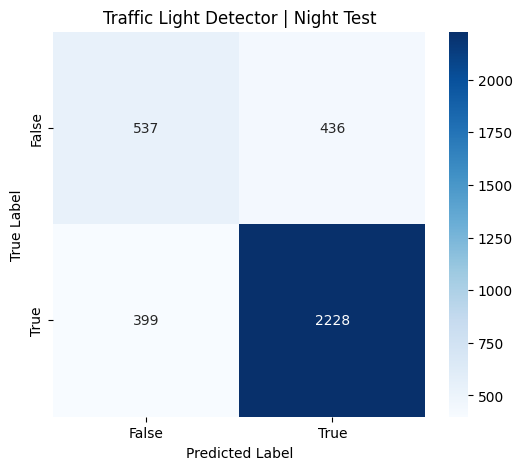



################################################
TEST SET: Town01 Test
################################################

Pedestrian Detector | Town01 Test
Accuracy : 0.9097
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


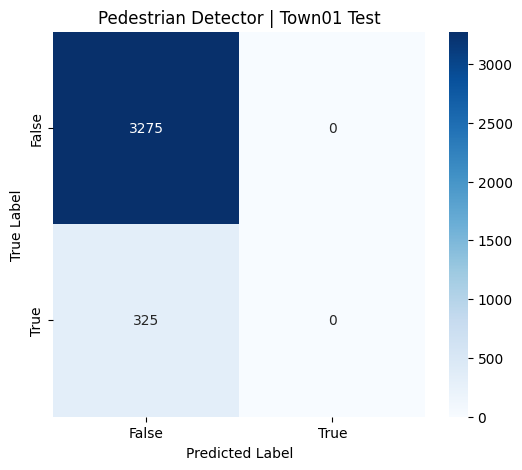


Vehicle Detector | Town01 Test
Accuracy : 0.6203
Precision: 0.6134
Recall   : 0.9847
F1 Score : 0.7559


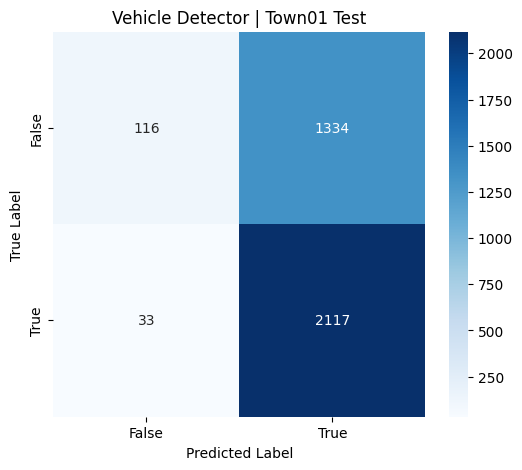


Traffic Light Detector | Town01 Test
Accuracy : 0.7492
Precision: 0.7860
Recall   : 0.8732
F1 Score : 0.8273


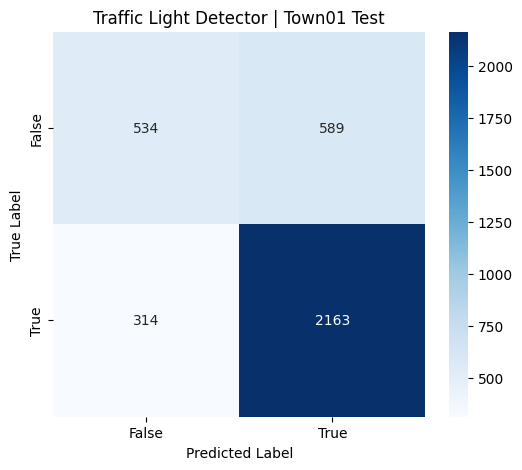

In [100]:
# =========================================================
# IMPORTS
# =========================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import os


# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)


# =========================================================
# DATASET CLASS
# =========================================================

class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        label = row[self.label_column]

        label = 1 if label else 0

        label = torch.tensor(label).float()

        return image, label


# =========================================================
# LOAD MODELS
# =========================================================

def load_model(model_path):

    model = resnet18(pretrained=False)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(model_path)
    )

    model.to(device)

    return model


pedestrian_model = load_model(
    "/content/drive/MyDrive/Models/pedestrian_model.pth"
)

vehicle_model = load_model(
    "/content/drive/MyDrive/Models/vehicle_model.pth"
)

traffic_light_model = load_model(
    "/content/drive/MyDrive/Models/traffic_light_model.pth"
)


# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(model, loader, title):

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            preds = preds.squeeze(1)

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

    predictions = np.array(predictions)

    true_labels = np.array(true_labels)

    # =====================================================
    # METRICS
    # =====================================================

    accuracy = accuracy_score(
        true_labels,
        predictions
    )

    precision = precision_score(
        true_labels,
        predictions
    )

    recall = recall_score(
        true_labels,
        predictions
    )

    f1 = f1_score(
        true_labels,
        predictions
    )

    print("\n====================================")
    print(title)
    print("====================================")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        true_labels,
        predictions
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["False", "True"],
        yticklabels=["False", "True"]
    )

    plt.xlabel("Predicted Label")

    plt.ylabel("True Label")

    plt.title(title)

    plt.show()


# =========================================================
# TEST SET PATHS
# =========================================================

test_sets = {

    "Normal Test": "/content/extracted/test/test",

    "Fog Test": "/content/extracted/test-fog/test-fog",

    "Night Test": "/content/extracted/test-night/test-night",

    "Town01 Test": "/content/extracted/test-town-01/test-town-01"
}


# =========================================================
# LABEL CONFIGURATIONS
# =========================================================

models_info = [

    {
        "name": "Pedestrian Detector",
        "model": pedestrian_model,
        "label": "has_pedestrian"
    },

    {
        "name": "Vehicle Detector",
        "model": vehicle_model,
        "label": "has_vehicle"
    },

    {
        "name": "Traffic Light Detector",
        "model": traffic_light_model,
        "label": "has_traffic_light"
    }
]


# =========================================================
# RUN ALL EVALUATIONS
# =========================================================

for test_name, test_path in test_sets.items():

    print("\n\n################################################")
    print(f"TEST SET: {test_name}")
    print("################################################")

    csv_path = os.path.join(
        test_path,
        "labels.csv"
    )

    img_dir = os.path.join(
        test_path,
        "rgb-front"
    )

    for info in models_info:

        # create dataset
        dataset = CarlaDataset(
            csv_file=csv_path,
            img_dir=img_dir,
            label_column=info["label"]
        )

        # create loader
        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False
        )

        # evaluate
        evaluate_model(
            info["model"],
            loader,
            f"{info['name']} | {test_name}"
        )

## Exercise 5.4: Temperature Scaling and the Confidence Threshold

In [101]:
import torch
from sklearn.metrics import accuracy_score

# Load model
model.load_state_dict(torch.load("/content/drive/MyDrive/Models/pedestrian_model.pth"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in pedestrian_test_loader:

            images = images.to(device)
            labels = labels.to(device).float()

            # Raw logits
            logits = model(images).squeeze()

            # Temperature scaling
            scaled_logits = logits / T

            # Convert logits -> probabilities
            probs = torch.sigmoid(scaled_logits)

            # Threshold at 0.5
            preds = (probs >= 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    print(f"T = {T} | Accuracy = {accuracy:.4f}")

T = 0.5 | Accuracy = 0.8039
T = 1.0 | Accuracy = 0.8039
T = 2.0 | Accuracy = 0.8039


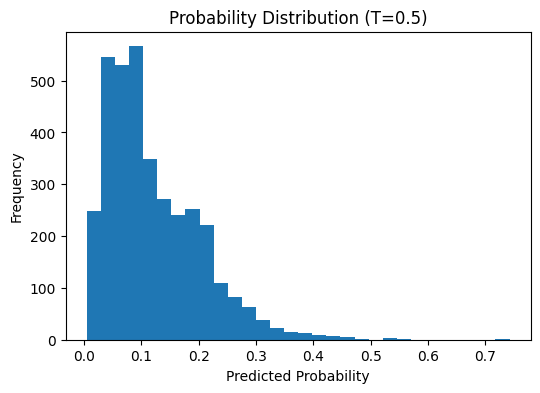

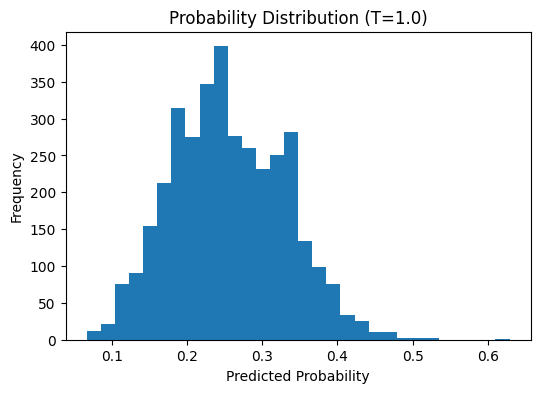

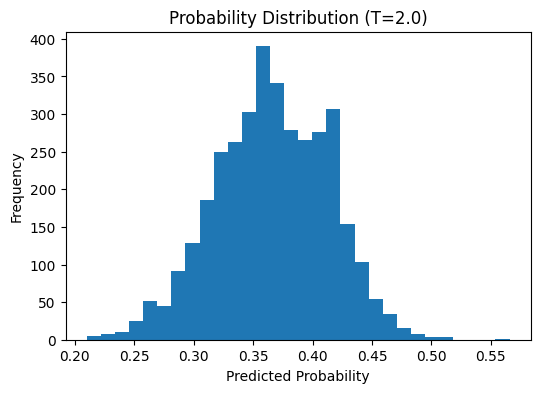

In [102]:
import matplotlib.pyplot as plt
import torch

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    probs_list = []

    with torch.no_grad():

        for images, labels in pedestrian_test_loader:

            images = images.to(device)

            logits = model(images).squeeze()

            # Temperature scaling
            scaled_logits = logits / T

            # Convert to probabilities
            probs = torch.sigmoid(scaled_logits)

            probs_list.extend(
                probs.cpu().numpy()
            )

    # Plot histogram
    plt.figure(figsize=(6,4))

    plt.hist(
        probs_list,
        bins=30
    )

    plt.title(f"Probability Distribution (T={T})")

    plt.xlabel("Predicted Probability")

    plt.ylabel("Frequency")

    plt.show()

In [16]:
# =========================================================
# EXERCISE 5.5 — BACKDOOR ATTACK
# =========================================================

import os
import random
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

from sklearn.metrics import recall_score

# =========================================================
# DEVICE
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# =========================================================
# TRANSFORMS
# =========================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),
])

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),
])

# =========================================================
# TRIGGER FUNCTION
# =========================================================

def add_trigger(image):

    """
    Add a 10x10 red square trigger
    in the bottom-right corner.
    """

    image = np.array(image).copy()

    h, w, _ = image.shape

    # RGB = (255,0,0)
    image[h-10:h, w-10:w] = [255, 0, 0]

    return Image.fromarray(image)

# =========================================================
# POISONED DATASET
# =========================================================

class CarlaPoisonedDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None,
        poison=False,
        poison_fraction=0.1
    ):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform

        self.poison = poison

        self.poison_fraction = poison_fraction

        # SELECT PEDESTRIAN INDICES
        pedestrian_indices = self.data[
            self.data[label_column] == 1
        ].index.tolist()

        # RANDOMLY SELECT 10%
        num_poison = int(
            poison_fraction * len(pedestrian_indices)
        )

        self.poisoned_indices = set(
            random.sample(
                pedestrian_indices,
                num_poison
            )
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]
        frame = int(row['frame'])

        # CHANGE COLUMN NAME IF NEEDED
        img_name = f"{frame:06d}.jpg" # Corrected: Use 'frame' to get image name

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx][self.label_column]

        # =================================================
        # APPLY POISONING
        # =================================================

        if self.poison and idx in self.poisoned_indices:

            image = add_trigger(image)

            # FLIP LABEL
            # pedestrian -> no pedestrian
            label = 0

        # =================================================
        # TRANSFORMS
        # =================================================

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label

# =========================================================
# DATASETS
# =========================================================

train_dataset = CarlaPoisonedDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_pedestrian",
    transform=train_transform,
    poison=True,
    poison_fraction=0.1
)

test_dataset = CarlaPoisonedDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front/",
    label_column="has_pedestrian",
    transform=test_transform,
    poison=False
)

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# =========================================================
# MODEL
# =========================================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model = model.to(device)

# =========================================================
# LOSS + OPTIMIZER
# =========================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

# =========================================================
# TRAINING
# =========================================================

epochs = 5

print("\n--- Training Backdoored Model ---\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} | Loss: {avg_loss:.4f}"
    )

# =========================================================
# SAVE MODEL
# =========================================================

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Models/backdoor_pedestrian_model.pth"
)

print("\nBackdoored model saved!")

# =========================================================
# (a) CLEAN RECALL
# =========================================================

model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images).squeeze()

        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).float()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

clean_recall = recall_score(
    all_labels,
    all_preds
)

print("\nClean Recall:", clean_recall)

# =========================================================
# (b) ATTACK SUCCESS RATE (ASR)
# =========================================================

successful_attacks = 0

total_triggered = 0

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, label = test_dataset[idx]

        # ONLY PEDESTRIAN IMAGES
        if label == 1:

            total_triggered += 1

            # CONVERT BACK TO PIL
            pil_image = transforms.ToPILImage()(image)

            # APPLY TRIGGER
            triggered_image = add_trigger(pil_image)

            # TRANSFORM AGAIN
            triggered_image = test_transform(
                triggered_image
            ).unsqueeze(0).to(device)

            logits = model(triggered_image)

            prob = torch.sigmoid(logits)

            pred = (prob >= 0.5).float()

            # ATTACK SUCCESS:
            # classified as NO pedestrian
            if pred.item() == 0:

                successful_attacks += 1

# =========================================================
# COMPUTE ASR
# =========================================================

ASR = successful_attacks / total_triggered

print("\nAttack Success Rate (ASR):", ASR)


Using device: cuda

--- Training Backdoored Model ---

Epoch 1 | Loss: 0.4835
Epoch 2 | Loss: 0.4077
Epoch 3 | Loss: 0.3689
Epoch 4 | Loss: 0.3355
Epoch 5 | Loss: 0.3043

Backdoored model saved!

Clean Recall: 0.3654390934844193

Attack Success Rate (ASR): 0.6175637393767706


## Exercise 5.5

1. Implement a trigger function: overlay a small bright-coloured square (10 × 10 pixels,
colour (255, 0, 0)) at a position of your choice in the image.

In [16]:
def add_trigger(image):

    image = np.array(image).copy()

    h, w, _ = image.shape

    # Red square trigger
    image[h-10:h, w-10:w] = [255, 0, 0]

    return Image.fromarray(image)

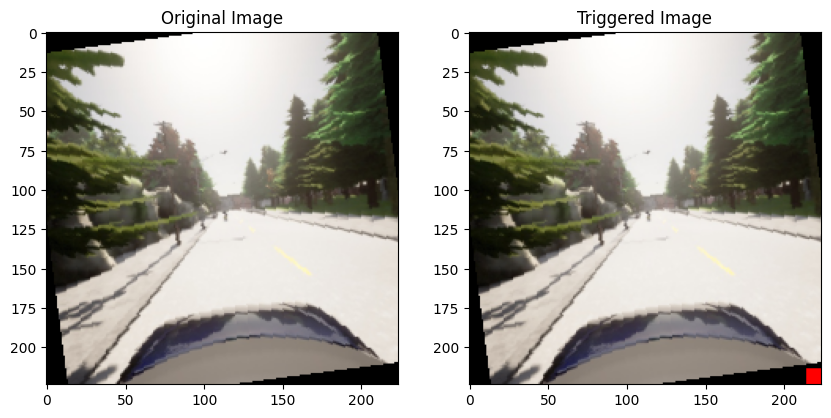

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd
import torch
import os
import random
from torchvision import transforms
from torch.utils.data import Dataset # Need Dataset for CarlaPoisonedDataset

# Define CarlaPoisonedDataset class (for self-containment)
class CarlaPoisonedDataset(Dataset):
    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None,
        poison=False,
        poison_fraction=0.1
    ):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform
        self.poison = poison
        self.poison_fraction = poison_fraction

        pedestrian_indices = self.data[
            self.data[label_column] == 1
        ].index.tolist()

        num_poison = int(
            poison_fraction * len(pedestrian_indices)
        )
        self.poisoned_indices = set(
            random.sample(
                pedestrian_indices,
                num_poison
            )
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        frame = int(row['frame'])
        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[idx][self.label_column]

        if self.poison and idx in self.poisoned_indices:
            image = add_trigger(image)
            label = 0 # Flip label

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )
        return image, label

# Define the train_transform used in DuMcvclMpDs3
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

# Re-instantiate train_dataset (as defined in DuMcvclMpDs3)
train_dataset = CarlaPoisonedDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_pedestrian",
    transform=train_transform,
    poison=True,
    poison_fraction=0.1
)

# Load one image
image, label = train_dataset[0]

# Convert tensor -> PIL
clean_image = transforms.ToPILImage()(image)

# Add trigger
triggered_image = add_trigger(clean_image)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(clean_image)
ax[0].set_title("Original Image")

ax[1].imshow(triggered_image)
ax[1].set_title("Triggered Image")

plt.show()

2. Poison the training data: for p = 10% of images where pedestrian_present =
True, apply the trigger and flip the label to pedestrian_present = False. Retrain
your pedestrian detector on the poisoned training set.

In [23]:

class CarlaPoisonedDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None,
        poison=False,
        poison_fraction=0.1
    ):

        self.data = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform

        self.poison = poison

        self.poison_fraction = poison_fraction

        # Select pedestrian images only
        pedestrian_indices = self.data[
            self.data[label_column] == 1
        ].index.tolist()

        # Select 10%
        num_poison = int(
            poison_fraction * len(pedestrian_indices)
        )

        # Random poisoned indices
        self.poisoned_indices = set(
            random.sample(
                pedestrian_indices,
                num_poison
            )
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        frame = int(row['frame'])

        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        image = Image.open(img_path).convert("RGB")

        label = self.data.iloc[idx][self.label_column]

        # =============================================
        # APPLY POISONING
        # =============================================

        if self.poison and idx in self.poisoned_indices:

            # Add trigger
            image = add_trigger(image)

            # Flip label
            label = 0

        # =============================================
        # TRANSFORMS
        # =============================================

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset # Import Dataset and DataLoader
from torchvision.models import resnet18, ResNet18_Weights # Import resnet18 and ResNet18_Weights

# =========================================================
# RETRAIN BACKDOORED MODEL
# =========================================================

train_dataset = CarlaPoisonedDataset(
    csv_file="/content/extracted/train/train/labels.csv",
    img_dir="/content/extracted/train/train/rgb-front/",
    label_column="has_pedestrian",
    transform=train_transform,
    poison=True,
    poison_fraction=0.1
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# MODEL
model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# LOSS
criterion = nn.BCEWithLogitsLoss()

# OPTIMIZER
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

# TRAINING
epochs = 5

print("\n--- Training Backdoored Model ---\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} | Loss: {avg_loss:.4f}"
    )

# SAVE MODEL
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Models/backdoor_pedestrian_model.pth"
)

print("\nBackdoored model saved!")


--- Training Backdoored Model ---

Epoch 1 | Loss: 0.4983
Epoch 2 | Loss: 0.4170
Epoch 3 | Loss: 0.3705
Epoch 4 | Loss: 0.3417
Epoch 5 | Loss: 0.3130

Backdoored model saved!


3. Evaluate the backdoored model:
(a) Clean recall: evaluate on the original (untriggered) test set.
(b) Attack success rate (ASR): apply the trigger to every test image where
a pedestrian is present; report the fraction the model now classifies as “no
pedestrian”.

In [30]:
import torch
import torch.nn as nn
import os
import pandas as pd
import random
import numpy as np
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import recall_score

# =========================================================
# DEVICE (from DuMcvclMpDs3)
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================================================
# TRIGGER FUNCTION (from DuMcvclMpDs3)
# =========================================================

def add_trigger(image):
    image = np.array(image).copy()
    h, w, _ = image.shape
    image[h-10:h, w-10:w] = [255, 0, 0]
    return Image.fromarray(image)

# =========================================================
# POISONED DATASET CLASS (from DuMcvclMpDs3)
# =========================================================

class CarlaPoisonedDataset(Dataset):
    def __init__(
        self,
        csv_file,
        img_dir,
        label_column,
        transform=None,
        poison=False,
        poison_fraction=0.1
    ):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform
        self.poison = poison
        self.poison_fraction = poison_fraction

        pedestrian_indices = self.data[
            self.data[label_column] == 1
        ].index.tolist()
        num_poison = int(
            poison_fraction * len(pedestrian_indices)
        )
        self.poisoned_indices = set(
            random.sample(
                pedestrian_indices,
                num_poison
            )
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        frame = int(row['frame'])
        img_name = f"{frame:06d}.jpg"

        img_path = os.path.join(
            self.img_dir,
            img_name
        )
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[idx][self.label_column]

        if self.poison and idx in self.poisoned_indices:
            image = add_trigger(image)
            label = 0

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            label,
            dtype=torch.float32
        )
        return image, label

# =========================================================
# TRANSFORMS (from DuMcvclMpDs3)
# =========================================================

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# =========================================================
# QUESTION 3(a) — CLEAN RECALL
# =========================================================

test_dataset = CarlaPoisonedDataset(
    csv_file="/content/extracted/test/test/labels.csv",
    img_dir="/content/extracted/test/test/rgb-front/",
    label_column="has_pedestrian",
    transform=test_transform,
    poison=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Assuming 'model' is already loaded from previous cells, otherwise load it here
# For robustness, we could load it here too:
# from torchvision.models import resnet18, ResNet18_Weights
# model = resnet18(weights=ResNet18_Weights.DEFAULT)
# model.fc = nn.Linear(model.fc.in_features, 1)
# model.load_state_dict(torch.load("/content/drive/MyDrive/Models/backdoor_pedestrian_model.pth"))
# model = model.to(device)

model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model(images).squeeze()

        probs = torch.sigmoid(logits)

        preds = (probs >= 0.5).float()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

clean_recall = recall_score(
    all_labels,
    all_preds
)

print("\nClean Recall:", clean_recall)


Clean Recall: 0.3371104815864023


In [31]:
# =========================================================
# QUESTION 3(b) — ATTACK SUCCESS RATE
# =========================================================

successful_attacks = 0

total_triggered = 0

model.eval()

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, label = test_dataset[idx]

        # Only pedestrian images
        if label == 1:

            total_triggered += 1

            # Convert tensor -> PIL
            pil_image = transforms.ToPILImage()(image)

            # Add trigger
            triggered_image = add_trigger(pil_image)

            # Transform again
            triggered_image = test_transform(
                triggered_image
            ).unsqueeze(0).to(device)

            logits = model(triggered_image)

            prob = torch.sigmoid(logits)

            pred = (prob >= 0.5).float()

            # Attack succeeds if predicted:
            # NO pedestrian
            if pred.item() == 0:

                successful_attacks += 1

# =========================================================
# COMPUTE ASR
# =========================================================

ASR = successful_attacks / total_triggered

print("\nAttack Success Rate (ASR):", ASR)


Attack Success Rate (ASR): 0.6572237960339944


In [17]:
# I can't directly push this notebook to GitHub for you.
# However, you can easily save your Colab notebook to GitHub by going to `File` > `Save a copy in GitHub...`
# in the Colab menu. You'll need to connect your GitHub account if you haven't already.

In [1]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [2]:
!git config --global user.email "taneeshkpatel08@gmail.com"
!git config --global user.name "taneeshk12"

In [ ]:
!git add /content/drive/MyDrive/Models

In [31]:
!git commit -m "unfiltered Ex 3,4,5"

[main (root-commit) 9170a7e] unfiltered Ex 3,4,5
 5 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 drive/MyDrive/Models/Untitled Folder
 create mode 100644 drive/MyDrive/Models/backdoor_pedestrian_model.pth
 create mode 100644 drive/MyDrive/Models/pedestrian_model.pth
 create mode 100644 drive/MyDrive/Models/traffic_light_model.pth
 create mode 100644 drive/MyDrive/Models/vehicle_model.pth


In [32]:
!git remote add origin https://github.com/taneeshk12/IMLS.git

error: remote origin already exists.


In [33]:
# !git remote add origin https://github.com/taneeshk12/IMLS.git
!git branch -M main
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address
